In [ ]:
# 구글드라이브 연결

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from torchvision import transforms

Mounted at /content/drive


In [ ]:
# 데이터 경로 설정

import os

DATA_DIR = "/content/drive/MyDrive/[시냅스] 서울 랜드마크 이미지 분류 모델/2026-1 시냅스 활동"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUBMISSION = os.path.join(DATA_DIR, "sample_submission.csv")

In [ ]:
print(os.path.exists(DATA_DIR))
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.path.exists(TRAIN_CSV))
print(os.path.exists(TEST_CSV))

True
True
True
True
True


In [ ]:
# csv 파일 읽기

import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)

print("train.csv 크기:", train_df.shape)
print("test.csv 크기:", test_df.shape)
print("sample_submission.csv 크기:", sample_submission.shape)

display(train_df.head())
display(test_df.head())
display(sample_submission.head())

train.csv 크기: (723, 2)
test.csv 크기: (199, 1)
sample_submission.csv 크기: (199, 2)


,file_name,label
0,001.PNG,9
1,002.PNG,4
2,003.PNG,1
3,004.PNG,1
4,005.PNG,6


,file_name
0,001.PNG
1,002.PNG
2,003.PNG
3,004.PNG
4,005.PNG


,file_name,label
0,001.PNG,0
1,002.PNG,0
2,003.PNG,0
3,004.PNG,0
4,005.PNG,0


In [ ]:
# 데이터 컬럼 확인
# file_name: 이미지 파일 이름
# label: 이미지의 정답 클래스

# 컬럼명 지정
IMAGE_COL = "file_name"
LABEL_COL = "label"


# 이미지 경로 생성
train_df["image_path"] = train_df[IMAGE_COL].apply(
    lambda x: os.path.join(TRAIN_DIR, x)
)

test_df["image_path"] = test_df[IMAGE_COL].apply(
    lambda x: os.path.join(TEST_DIR, x)
)

display(train_df.head())
display(test_df.head())

,file_name,label,image_path
0,001.PNG,9,/content/drive/MyDrive/[시냅스] 서울 랜드마...
1,002.PNG,4,/content/drive/MyDrive/[시냅스] 서울 랜드마...
2,003.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...
3,004.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...
4,005.PNG,6,/content/drive/MyDrive/[시냅스] 서울 랜드마...


,file_name,image_path
0,001.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
1,002.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
2,003.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
3,004.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...
4,005.PNG,/content/drive/MyDrive/[시냅스] 서울 랜드마...


In [ ]:
# 이미지 파일 존재 확인

print(train_df.loc[0, "image_path"])
print(os.path.exists(train_df.loc[0, "image_path"]))

print(test_df.loc[0, "image_path"])
print(os.path.exists(test_df.loc[0, "image_path"]))

/content/drive/MyDrive/[시냅스] 서울 랜드마크 이미지 분류 모델/2026-1 시냅스 활동/train/001.PNG
True
/content/drive/MyDrive/[시냅스] 서울 랜드마크 이미지 분류 모델/2026-1 시냅스 활동/test/001.PNG
True


In [ ]:
# 클래스 확인, 라벨 정리

classes = sorted(train_df[LABEL_COL].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

train_df["label_idx"] = train_df[LABEL_COL].map(class_to_idx)

print("클래스 개수:", len(classes))
print("클래스 목록:", classes)

display(train_df.head())

클래스 개수: 10
클래스 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,file_name,label,image_path,label_idx
0,001.PNG,9,/content/drive/MyDrive/[시냅스] 서울 랜드마...,9
1,002.PNG,4,/content/drive/MyDrive/[시냅스] 서울 랜드마...,4
2,003.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...,1
3,004.PNG,1,/content/drive/MyDrive/[시냅스] 서울 랜드마...,1
4,005.PNG,6,/content/drive/MyDrive/[시냅스] 서울 랜드마...,6


In [ ]:
# 1. train / validation 분리

from sklearn.model_selection import train_test_split

train_data, valid_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label_idx"]
)

print("학습 데이터 개수:", len(train_data))
print("검증 데이터 개수:", len(valid_data))

학습 데이터 개수: 578
검증 데이터 개수: 145


In [ ]:
# 2. 이미지 전처리
# transform: AI가 이미지를 보기 좋게 바꾸는 작업

from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),  # 모든 이미지 크기 통일

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),  # 이미지를 PyTorch tensor로 변환

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# 3. CustomDataset 만들기

from PIL import Image
import torch
from torch.utils.data import Dataset

class LandmarkDataset(Dataset):

    def __init__(self, dataframe, transform=None, is_test=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image

        label = self.dataframe.loc[idx, "label_idx"]
        label = torch.tensor(label, dtype=torch.long)

        return image, label

- LandmarkDataset
    - 이미지 경로 확인
    - → 이미지 열기
    - → 전처리 적용
    - → 이미지와 라벨 반환

In [ ]:
# 4. Dataset 생성

train_dataset = LandmarkDataset(
    train_data,
    transform=train_transform,
    is_test=False
)

valid_dataset = LandmarkDataset(
    valid_data,
    transform=valid_transform,
    is_test=False
)

test_dataset = LandmarkDataset(
    test_df,
    transform=valid_transform,
    is_test=True
)

print("train_dataset 개수:", len(train_dataset))
print("valid_dataset 개수:", len(valid_dataset))
print("test_dataset 개수:", len(test_dataset))

train_dataset 개수: 578
valid_dataset 개수: 145
test_dataset 개수: 199


In [ ]:
# 5. DataLoader 생성

from torch.utils.data import DataLoader

# 32장씩 묶어서 모델에게 전달함
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True # 32장씩 묶어서 모델에게 전닳
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoader 생성 완료!")

DataLoader 생성 완료!


In [ ]:
# 6. DataLoader 확인 코드

images, labels = next(iter(train_loader))

print("이미지 배치 크기:", images.shape)
print("라벨 배치 크기:", labels.shape)
print("첫 번째 라벨:", labels[0])

이미지 배치 크기: torch.Size([32, 3, 224, 224])
라벨 배치 크기: torch.Size([32])
첫 번째 라벨: tensor(2)


### 데이터 증강 실험

#### 실험1 증강 없는 버전

In [ ]:
# 실험1 증강 없는 버전

basic_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# 데이터셋

basic_train_dataset = LandmarkDataset(
    train_data,
    transform=basic_transform,
    is_test=False
)

basic_valid_dataset = LandmarkDataset(
    valid_data,
    transform=valid_transform,
    is_test=False
)

In [ ]:
# DataLoader

basic_train_loader = DataLoader(
    basic_train_dataset,
    batch_size=32,
    shuffle=True
)

basic_valid_loader = DataLoader(
    basic_valid_dataset,
    batch_size=32,
    shuffle=False
)

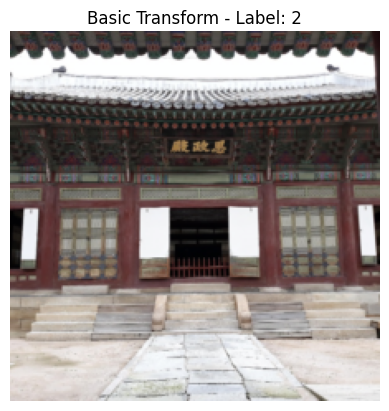

In [ ]:
import matplotlib.pyplot as plt

image, label = basic_train_dataset[0]

image = image.permute(1, 2, 0).numpy()

image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
image = image.clip(0, 1)

plt.imshow(image)
plt.title(f"Basic Transform - Label: {label}")
plt.axis("off")
plt.show()

#### 실험2 기본 증강 버전

In [ ]:
# 실험2 기본 증강 버전

aug_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),  # -10도 ~ +10도

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# 데이터셋

aug_train_dataset = LandmarkDataset(
    train_data,
    transform=aug_transform,
    is_test=False
)

aug_valid_dataset = LandmarkDataset(
    valid_data,
    transform=valid_transform,
    is_test=False
)

In [ ]:
# DataLoader

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=32,
    shuffle=True
)

aug_valid_loader = DataLoader(
    aug_valid_dataset,
    batch_size=32,
    shuffle=False
)

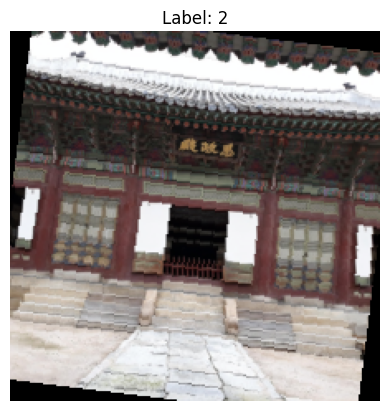

In [ ]:
import matplotlib.pyplot as plt

image, label = aug_train_dataset[0]

image = image.permute(1, 2, 0).numpy()

image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
image = image.clip(0, 1)

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

#### ColorJitter

In [ ]:
strong_aug_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

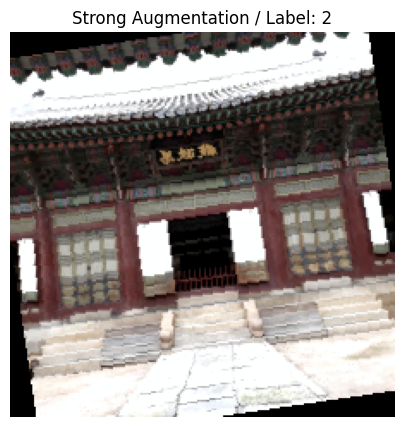

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# strong augmentation dataset 생성
strong_aug_train_dataset = LandmarkDataset(
    train_data,
    transform=strong_aug_transform,
    is_test=False
)

# 이미지 가져오기
image, label = strong_aug_train_dataset[0]

# tensor -> numpy 변환
image = image.permute(1, 2, 0).numpy()

# 정규화 복원
image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])

# 픽셀 범위 조정
image = image.clip(0, 1)

# 시각화
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title(f"Strong Augmentation / Label: {label}")
plt.axis("off")
plt.show()

| 종류                  | 적용 내용                                   |
| ------------------- | --------------------------------------- |
| Basic Transform     | Resize + Normalize                      |
| Basic Augmentation  | HorizontalFlip + Rotation               |
| Strong Augmentation | HorizontalFlip + Rotation + ColorJitter |
